# Load all datasets

In [8]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
room_conditions = pd.read_csv('../data/raw/room_conditions.csv')
room_conditions.head()


,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,23.7000,26.272,585.200000,749.200000,0.004764,1
1,23.7180,26.290,578.400000,760.400000,0.004773,1
2,23.7300,26.230,572.666667,769.666667,0.004765,1
3,23.7225,26.125,493.750000,774.750000,0.004744,1
4,23.7540,26.200,488.600000,779.000000,0.004767,1


In [11]:
data = room_conditions.copy()

# drop occupancy column
data = data.drop('Occupancy', axis=1)

# drop humidity ratio column
data = data.drop('HumidityRatio', axis=1)

data.head()

,Temperature,Humidity,Light,CO2
0,23.7000,26.272,585.200000,749.200000
1,23.7180,26.290,578.400000,760.400000
2,23.7300,26.230,572.666667,769.666667
3,23.7225,26.125,493.750000,774.750000
4,23.7540,26.200,488.600000,779.000000


In [12]:
# Shape of data
print(f'Shape of data: {data.shape}')

Shape of data: (2665, 4)


Now the time difference between the measurements has to be taken into account to be able to calculate features like temp_max_30min, and similar. 
Because the dataset does not disclose the exact time of the measurements, it will be roughly calculated based on the rate of change of individual variables.

In [ ]:
# Analyse any suspicious jumps of values between measurements
data_diff = data.diff().abs()
data_diff.describe()

,Temperature,Humidity,Light,CO2
count,2664.000000,2664.000000,2664.000000,2664.000000
mean,0.014224,0.032614,3.421995,3.802458
std,0.020607,0.044862,25.455092,3.715309
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.250000
50%,0.000000,0.022500,0.000000,2.833333
75%,0.025000,0.050000,1.000000,5.166667
max,0.110000,0.993000,652.500000,51.050000


Out of the features temp, humidity, light, co2, some of them can't change too much in a short time. "Too much" in objective terms can be described as a deviation from the mean difference between consecutive measurements. 

Total rows: 2665
Multiplier std: 1, Number of sessions: 824
Multiplier std: 2, Number of sessions: 285
Multiplier std: 3, Number of sessions: 91
Multiplier std: 4, Number of sessions: 44
Multiplier std: 5, Number of sessions: 21
Multiplier std: 6, Number of sessions: 11
Multiplier std: 7, Number of sessions: 7
Multiplier std: 8, Number of sessions: 6
Multiplier std: 9, Number of sessions: 4


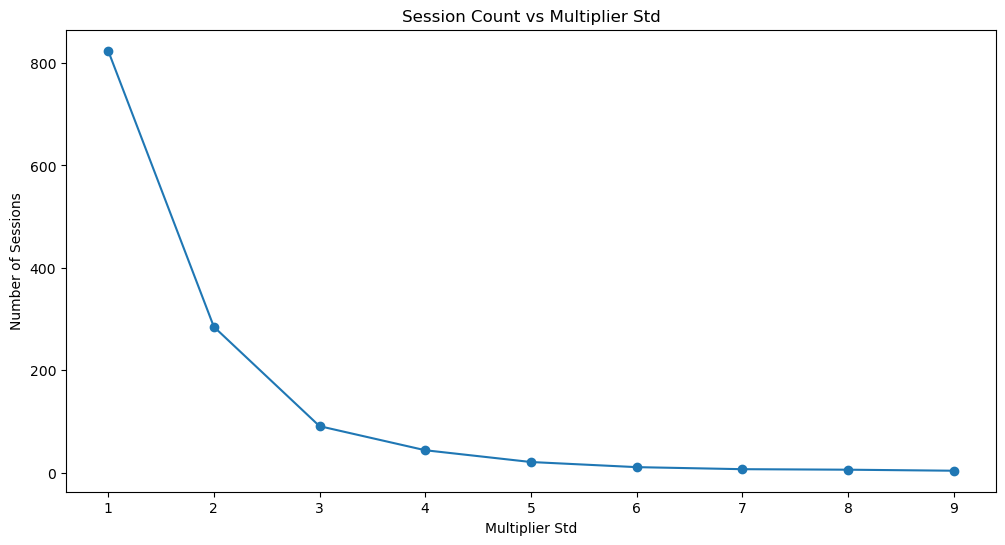

In [23]:
# Getting max allowed jump in each variable to be considered as a normal change

multiplier_std = 6

max_jump_temp = data_diff['Temperature'].mean() + multiplier_std * data_diff['Temperature'].std()
max_jump_humidity = data_diff['Humidity'].mean() + multiplier_std * data_diff['Humidity'].std()
max_jump_light = data_diff['Light'].mean() + multiplier_std * data_diff['Light'].std()
max_jump_co2 = data_diff['CO2'].mean() + multiplier_std * data_diff['CO2'].std()

# Splitting data into sessions based on jumps in values for temp, humidity, co2 (light can change) - comparing mean with difference

sessions = (data_diff['Temperature'] > max_jump_temp) | (data_diff['Humidity'] > max_jump_humidity) | (data_diff['CO2'] > max_jump_co2)
sessions = sessions.cumsum()

# Trying different values of multiplier_std to see how many sessions it yields
print(f"Total rows: {data.shape[0]}")
for multiplier_std in range(1, 10):
    max_jump_temp = data_diff['Temperature'].mean() + multiplier_std * data_diff['Temperature'].std()
    max_jump_humidity = data_diff['Humidity'].mean() + multiplier_std * data_diff['Humidity'].std()
    max_jump_light = data_diff['Light'].mean() + multiplier_std * data_diff['Light'].std()
    max_jump_co2 = data_diff['CO2'].mean() + multiplier_std * data_diff['CO2'].std()

    sessions = (data_diff['Temperature'] > max_jump_temp) | (data_diff['Humidity'] > max_jump_humidity) | (data_diff['CO2'] > max_jump_co2)
    sessions = sessions.cumsum()

    print(f'Multiplier std: {multiplier_std}, Number of sessions: {sessions.nunique()}')
    
# Visualized session count vs multiplier_std

plt.figure(figsize=(12, 6))
multiplier_stds = range(1, 10)
session_counts = []
for multiplier_std in multiplier_stds:
    max_jump_temp = data_diff['Temperature'].mean() + multiplier_std * data_diff['Temperature'].std()
    max_jump_humidity = data_diff['Humidity'].mean() + multiplier_std * data_diff['Humidity'].std()
    max_jump_light = data_diff['Light'].mean() + multiplier_std * data_diff['Light'].std()
    max_jump_co2 = data_diff['CO2'].mean() + multiplier_std * data_diff['CO2'].std()

    sessions = (data_diff['Temperature'] > max_jump_temp) | (data_diff['Humidity'] > max_jump_humidity) | (data_diff['CO2'] > max_jump_co2)
    sessions = sessions.cumsum()

    session_counts.append(sessions.nunique())

plt.plot(multiplier_stds, session_counts, marker='o')
plt.xlabel('Multiplier Std')
plt.ylabel('Number of Sessions')
plt.title('Session Count vs Multiplier Std')
plt.show()

In [ ]:
# Max allowed jump in each variable to be considered as a normal change

Temperature is in celcius, humidity in percentage, light in lux, CO2 in ppm.
Based on the rate of change per unit of time with jumps (different sessions) accounted for:

# Mocking Target

The plan is to create a deterministic function that asses the room conditions based on some personality profile and then outputs the rating of the current conditions of the room on a scale. Then random noise is added to this and in general this gives the target variable for the model to predict. 